In [1]:
# ============================================================
# CELL 1 — Import Libraries
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, accuracy_score)
import joblib

print("✅ All libraries imported!")

✅ All libraries imported!


In [2]:
# ============================================================
# CELL 2 — Load & Prepare Data
# ============================================================

file_path = '/Users/aishwaryadeshwal/Desktop/customer-churn-prediction/data/processed/churn_cleaned.csv'
df = pd.read_csv(file_path)

# Convert target to binary
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Convert all categorical columns using get_dummies
df_encoded = pd.get_dummies(df, drop_first=True)

# Fill any NaN
df_encoded = df_encoded.fillna(df_encoded.median())

# Confirm no NaN
print(f"NaN values: {df_encoded.isnull().sum().sum()}")
print(f"Shape: {df_encoded.shape}")
print(f"Churn distribution:\n{df_encoded['Churn'].value_counts()}")

NaN values: 0
Shape: (7043, 31)
Churn distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [3]:
# ============================================================
# CELL 3 — Split Data
# ============================================================

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("✅ Data split done!")
print(f"🔵 Training : {X_train.shape[0]} customers")
print(f"🟢 Testing  : {X_test.shape[0]} customers")

✅ Data split done!
🔵 Training : 5634 customers
🟢 Testing  : 1409 customers


In [4]:
# ============================================================
# CELL 4 — Logistic Regression
# ============================================================

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)
lr_prob = lr_model.predict_proba(X_test)[:, 1]

lr_accuracy = accuracy_score(y_test, lr_pred)
lr_roc_auc  = roc_auc_score(y_test, lr_prob)

print("=" * 50)
print("MODEL 1 — LOGISTIC REGRESSION")
print("=" * 50)
print(f"✅ Accuracy : {lr_accuracy*100:.2f}%")
print(f"✅ ROC-AUC  : {lr_roc_auc:.4f}")
print("\n📊 Classification Report:")
print(classification_report(y_test, lr_pred,
      target_names=['No Churn', 'Churned']))

MODEL 1 — LOGISTIC REGRESSION
✅ Accuracy : 80.70%
✅ ROC-AUC  : 0.8417

📊 Classification Report:
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
     Churned       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [5]:
# ============================================================
# CELL 5 — Random Forest
# ============================================================

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=10
)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_roc_auc  = roc_auc_score(y_test, rf_prob)

print("=" * 50)
print("MODEL 2 — RANDOM FOREST")
print("=" * 50)
print(f"✅ Accuracy : {rf_accuracy*100:.2f}%")
print(f"✅ ROC-AUC  : {rf_roc_auc:.4f}")
print("\n📊 Classification Report:")
print(classification_report(y_test, rf_pred,
      target_names=['No Churn', 'Churned']))

MODEL 2 — RANDOM FOREST
✅ Accuracy : 80.34%
✅ ROC-AUC  : 0.8405

📊 Classification Report:
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
     Churned       0.66      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



In [6]:
# ============================================================
# CELL 6 — Compare & Save Models
# ============================================================

# Comparison table
comparison = pd.DataFrame({
    'Model'    : ['Logistic Regression', 'Random Forest'],
    'Accuracy' : [round(lr_accuracy*100, 2), round(rf_accuracy*100, 2)],
    'ROC-AUC'  : [round(lr_roc_auc, 4), round(rf_roc_auc, 4)]
})

print("=" * 50)
print("📊 FINAL MODEL COMPARISON")
print("=" * 50)
print(comparison.to_string(index=False))

# Best model
best = comparison.loc[comparison['ROC-AUC'].idxmax(), 'Model']
print(f"\n🏆 Best Model: {best}")

# Save models
path = '/Users/aishwaryadeshwal/Desktop/customer-churn-prediction/models/'
joblib.dump(lr_model, path + 'logistic_regression.pkl')
joblib.dump(rf_model, path + 'random_forest.pkl')
joblib.dump(scaler,   path + 'scaler.pkl')

print("\n✅ All models saved to models/ folder!")

📊 FINAL MODEL COMPARISON
              Model  Accuracy  ROC-AUC
Logistic Regression     80.70   0.8417
      Random Forest     80.34   0.8405

🏆 Best Model: Logistic Regression

✅ All models saved to models/ folder!


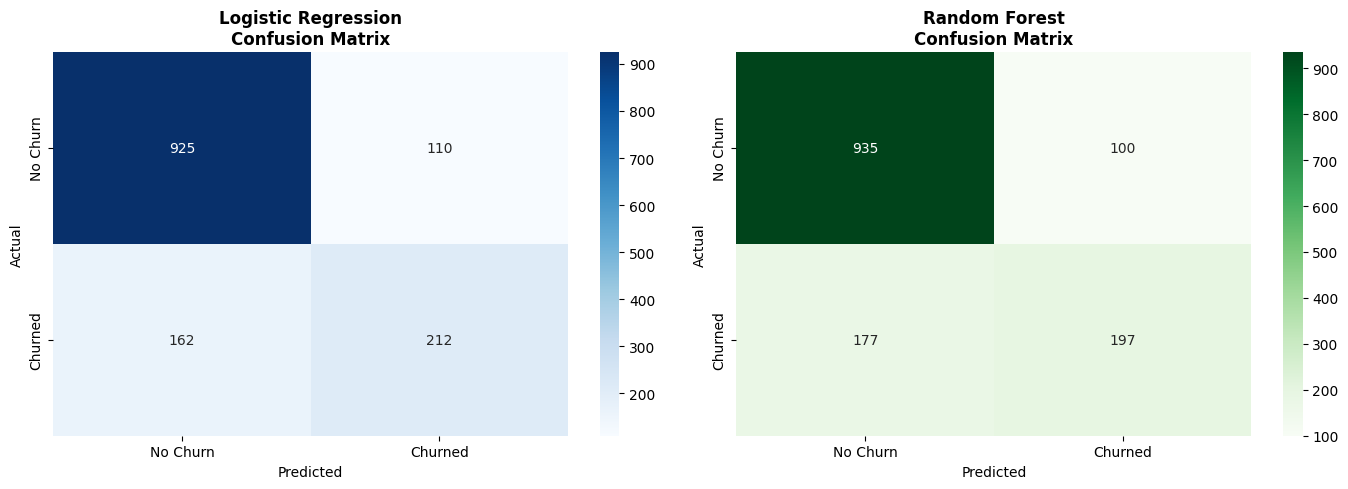

✅ Confusion matrix saved!


In [7]:
# ============================================================
# CELL 7 — Confusion Matrix
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models      = [lr_pred, rf_pred]
model_names = ['Logistic Regression', 'Random Forest']
colors      = ['Blues', 'Greens']

for i, (pred, name, color) in enumerate(zip(models, model_names, colors)):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(
        cm, annot=True, fmt='d',
        cmap=color, ax=axes[i],
        xticklabels=['No Churn', 'Churned'],
        yticklabels=['No Churn', 'Churned']
    )
    axes[i].set_title(f'{name}\nConfusion Matrix', fontweight='bold')
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

plt.tight_layout()
save_path = '/Users/aishwaryadeshwal/Desktop/customer-churn-prediction/reports/figures/09_confusion_matrix.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrix saved!")

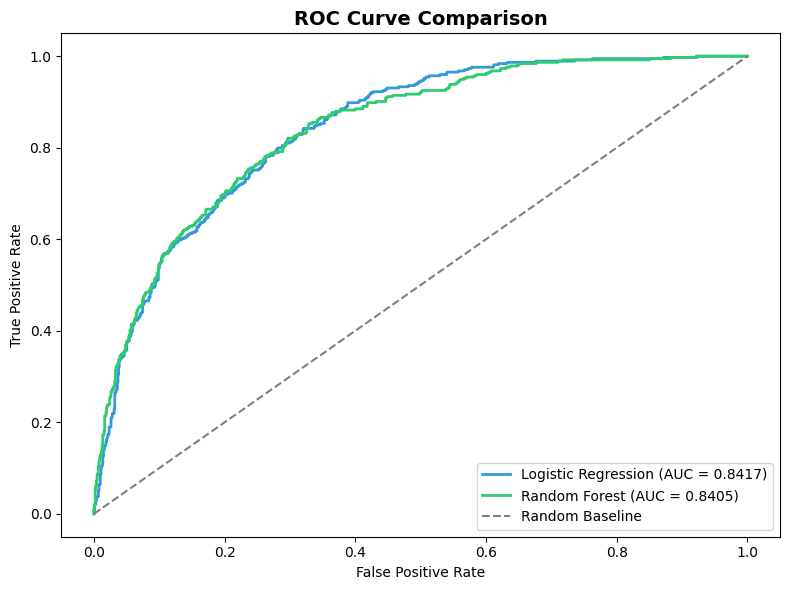

✅ ROC curve saved!


In [8]:
# ============================================================
# CELL 8 — ROC Curve
# ============================================================

plt.figure(figsize=(8, 6))

# Logistic Regression ROC
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
plt.plot(lr_fpr, lr_tpr,
         label=f'Logistic Regression (AUC = {lr_roc_auc:.4f})',
         color='#3498db', linewidth=2)

# Random Forest ROC
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
plt.plot(rf_fpr, rf_tpr,
         label=f'Random Forest (AUC = {rf_roc_auc:.4f})',
         color='#2ecc71', linewidth=2)

# Random baseline
plt.plot([0, 1], [0, 1],
         color='gray', linestyle='--',
         label='Random Baseline')

plt.title('ROC Curve Comparison', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()

save_path = '/Users/aishwaryadeshwal/Desktop/customer-churn-prediction/reports/figures/10_roc_curve.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print("✅ ROC curve saved!")

In [9]:
# ============================================================
# CELL 9 — Feature Importance
# ============================================================

# Get column names directly from X before scaling
X_cols = pd.get_dummies(
    pd.read_csv('/Users/aishwaryadeshwal/Desktop/customer-churn-prediction/data/processed/churn_cleaned.csv').drop('Churn', axis=1),
    drop_first=True
).columns.tolist()

# Create importance dataframe
importance_df = pd.DataFrame({
    'Feature'    : X_cols,
    'Importance' : rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

print("📊 Top 10 Most Important Features:")
print(importance_df.to_string(index=False))

📊 Top 10 Most Important Features:
                       Feature  Importance
                        tenure    0.196177
                  TotalCharges    0.163628
                MonthlyCharges    0.120351
   InternetService_Fiber optic    0.064681
PaymentMethod_Electronic check    0.060948
             Contract_Two year    0.056260
            OnlineSecurity_Yes    0.032920
             Contract_One year    0.032140
               TechSupport_Yes    0.023623
          PaperlessBilling_Yes    0.022699


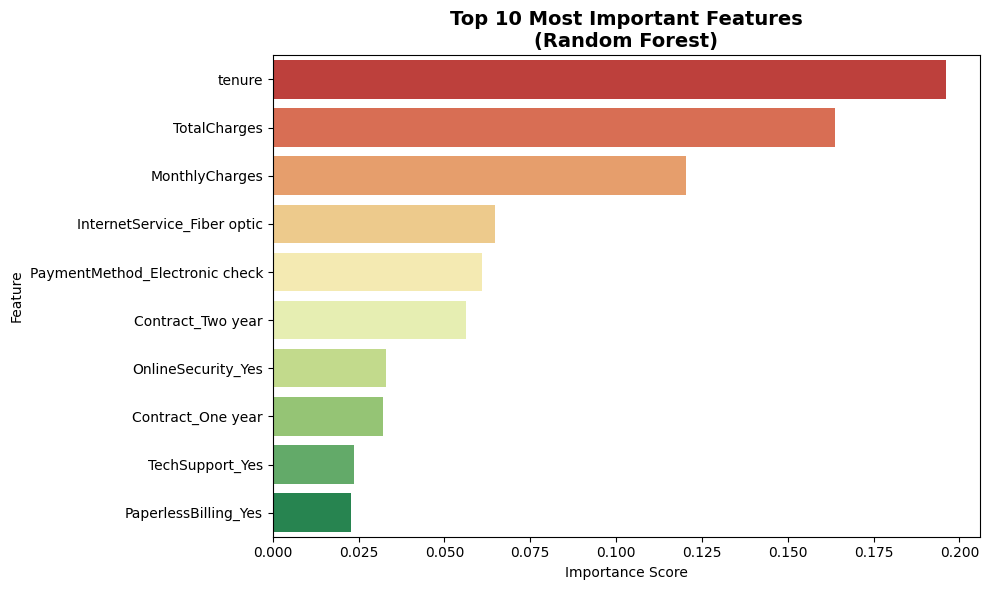

✅ Chart saved!


In [10]:
# ============================================================
# CELL 10 — Feature Importance Chart
# ============================================================

plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance_df,
    x='Importance',
    y='Feature',
    palette='RdYlGn'
)
plt.title('Top 10 Most Important Features\n(Random Forest)',
          fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()

save_path = '/Users/aishwaryadeshwal/Desktop/customer-churn-prediction/reports/figures/11_feature_importance.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")